# Phase 1.5: Refined Training & Visualization

## Objective
Continue training the 3D Attention U-Net from the previous checkpoint (`best_metric_model.pth`).
This session runs for **20 more epochs** with **visualizations after every epoch** to track progress.

In [1]:
# Dependencies
import os
import glob
import matplotlib.pyplot as plt
import numpy as np
import torch
from monai.config import print_config
from monai.data import DataLoader, decollate_batch, Dataset
from monai.losses import DiceLoss
from monai.inferers import sliding_window_inference
from monai.metrics import DiceMetric
from monai.networks.nets import AttentionUnet
from monai.transforms import (
    Compose,
    LoadImaged,
    NormalizeIntensityd,
    Orientationd,
    RandFlipd,
    RandScaleIntensityd,
    RandShiftIntensityd,
    RandSpatialCropd,
    Spacingd,
    EnsureChannelFirstd,
    EnsureTyped,
    ConvertToMultiChannelBasedOnBratsClassesd,
)
from monai.utils import set_determinism

print_config()
set_determinism(seed=0)

# Check for Checkpoint
if not os.path.exists("best_metric_model.pth"):
    raise FileNotFoundError("Could not find 'best_metric_model.pth'. Make sure you ran dataset_step1.ipynb first!")
else:
    print("Found checkpoint: best_metric_model.pth")


MONAI version: 1.5.1
Numpy version: 1.26.4
Pytorch version: 2.9.1+cpu
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: 9c6d819f97e37f36c72f3bdfad676b455bd2fa0d
MONAI __file__: C:\Users\<username>\AppData\Local\Programs\Python\Python311\Lib\site-packages\monai\__init__.py

Optional dependencies:
Pytorch Ignite version: NOT INSTALLED or UNKNOWN VERSION.
ITK version: 5.4.5
Nibabel version: 5.3.3
scikit-image version: NOT INSTALLED or UNKNOWN VERSION.
scipy version: 1.16.0
Pillow version: 11.3.0
Tensorboard version: 2.15.2
gdown version: NOT INSTALLED or UNKNOWN VERSION.
TorchVision version: NOT INSTALLED or UNKNOWN VERSION.
tqdm version: 4.67.1
lmdb version: 1.7.5
psutil version: 7.0.0
pandas version: 2.3.1
einops version: 0.8.1
transformers version: 4.44.2
mlflow version: NOT INSTALLED or UNKNOWN VERSION.
pynrrd version: 1.1.3
clearml version: NOT INSTALLED or UNKNOWN VERSION.

For details about installing the optional dependencies, please visit:
 

In [2]:
# --- CONFIGURATION ---
data_dir = "BraTS2021_Training_Data" 
BATCH_SIZE = 1 
EXTRA_EPOCHS = 20
VAL_INTERVAL = 1
LR = 1e-4
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [3]:
# --- DATASET SETUP ---
def get_brats_file_list(data_dir):
    train_images = sorted(glob.glob(os.path.join(data_dir, "BraTS2021_*", "*flair.nii.gz")))
    train_labels = sorted(glob.glob(os.path.join(data_dir, "BraTS2021_*", "*seg.nii.gz")))
    data_dicts = []
    for image_name, label_name in zip(train_images, train_labels):
        root = os.path.dirname(image_name)
        basename = os.path.basename(image_name).replace("_flair.nii.gz", "")
        t1 = os.path.join(root, f"{basename}_t1.nii.gz")
        t1ce = os.path.join(root, f"{basename}_t1ce.nii.gz")
        t2 = os.path.join(root, f"{basename}_t2.nii.gz")
        flair = os.path.join(root, f"{basename}_flair.nii.gz")
        seg = label_name
        if all(os.path.exists(p) for p in [t1, t1ce, t2, flair, seg]):
            data_dicts.append({"image": [t1, t1ce, t2, flair], "label": seg})
    return data_dicts

full_data = get_brats_file_list(data_dir)
train_size = int(0.8 * len(full_data))
train_files, val_files = full_data[:train_size], full_data[train_size:]

train_transform = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image"]),
    EnsureTyped(keys=["image", "label"]),
    ConvertToMultiChannelBasedOnBratsClassesd(keys="label"),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    Spacingd(keys=["image", "label"], pixdim=(1.0, 1.0, 1.0), mode=("bilinear", "nearest")),
    RandSpatialCropd(keys=["image", "label"], roi_size=[96, 96, 96], random_size=False),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=0),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=1),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=2),
    NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
    RandScaleIntensityd(keys="image", factors=0.1, prob=1.0),
    RandShiftIntensityd(keys="image", offsets=0.1, prob=1.0),
])

val_transform = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image"]),
    EnsureTyped(keys=["image", "label"]),
    ConvertToMultiChannelBasedOnBratsClassesd(keys="label"),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    Spacingd(keys=["image", "label"], pixdim=(1.0, 1.0, 1.0), mode=("bilinear", "nearest")),
    NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
])

train_ds = Dataset(data=train_files, transform=train_transform)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_ds = Dataset(data=val_files, transform=val_transform)
val_loader = DataLoader(val_ds, batch_size=1, shuffle=False, num_workers=2)

monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.


In [4]:
# --- MODEL LOADING ---
model = AttentionUnet(
    spatial_dims=3,
    in_channels=4,
    out_channels=3,
    channels=(16, 32, 64, 128, 256),
    strides=(2, 2, 2, 2),
).to(device)

# LOAD WEIGHTS
model.load_state_dict(torch.load("best_metric_model.pth"))
print("Loaded model weights from best_metric_model.pth")

loss_function = DiceLoss(sigmoid=True, squared_pred=True, smooth_nr=0, smooth_dr=1e-5)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
dice_metric = DiceMetric(include_background=True, reduction="mean", get_not_nans=False)

Loaded model weights from best_metric_model.pth


In [5]:
# --- VISUALIZATION FUNCTION ---
def visualize_results(model, loader, device, num_samples=3, epoch=0):
    model.eval()
    count = 0
    with torch.no_grad():
        for batch_data in loader:
            if count >= num_samples: break
            
            inputs, labels = batch_data["image"].to(device), batch_data["label"].to(device)
            outputs = sliding_window_inference(inputs, (96, 96, 96), 4, model)
            outputs = (outputs > 0.5).float()

            # Slice index 48 (center)
            val_img = inputs[0, 3, :, :, 48].cpu().numpy() # FLAIR
            val_seg = labels[0, 0, :, :, 48].cpu().numpy() # WT
            val_pred = outputs[0, 0, :, :, 48].cpu().numpy() 

            plt.figure(figsize=(12, 4))
            plt.suptitle(f"Epoch {epoch} - Sample {count+1}")
            plt.subplot(1, 3, 1); plt.title("Image (FLAIR)"); plt.imshow(val_img, cmap="gray", origin="lower"); plt.axis("off")
            plt.subplot(1, 3, 2); plt.title("Ground Truth (WT)"); plt.imshow(val_seg, cmap="gray", origin="lower"); plt.axis("off")
            plt.subplot(1, 3, 3); plt.title("Prediction (WT)"); plt.imshow(val_pred, cmap="gray", origin="lower"); plt.axis("off")
            plt.show()
            count += 1

Continuing training for 20 epochs...
----------
Refined Epoch 1/20
200/1000, train_loss: 0.3709
400/1000, train_loss: 0.9971
600/1000, train_loss: 0.9943
800/1000, train_loss: 1.0000
1000/1000, train_loss: 0.1069
Epoch 1 Avg Loss: 0.5767


Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\python_variable_indexing.cpp:351.)
Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\python_variable_indexing.cpp:351.)


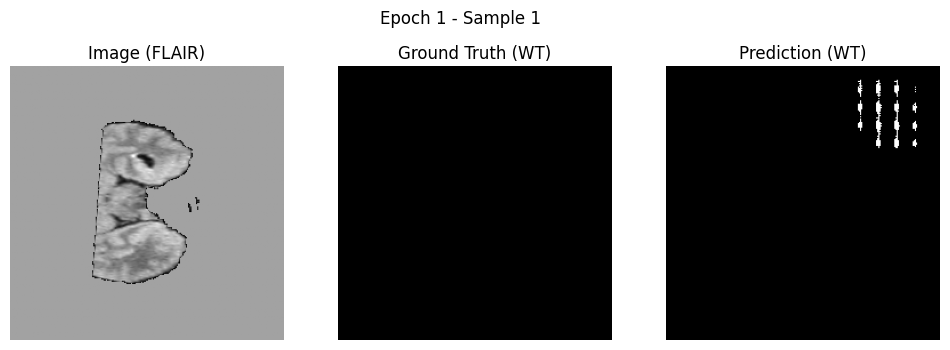

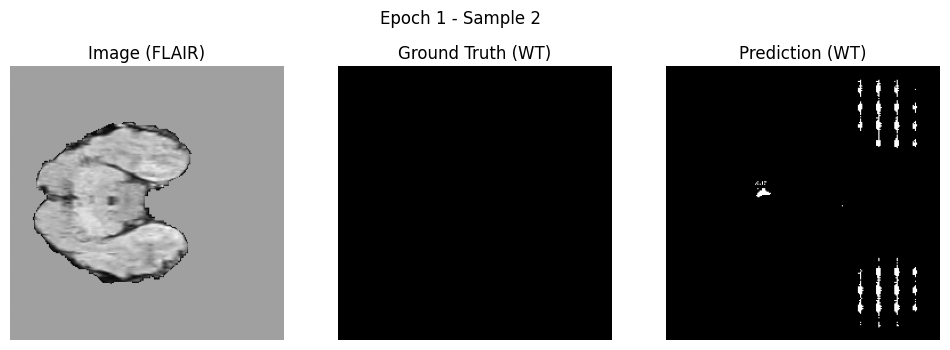

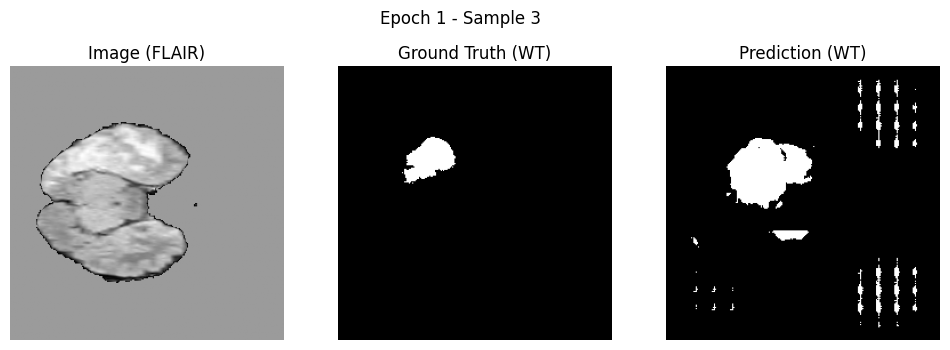

Current Mean Dice: 0.4877
Saved new best model refined.
----------
Refined Epoch 2/20
200/1000, train_loss: 0.3333
400/1000, train_loss: 0.9016
600/1000, train_loss: 0.6767
800/1000, train_loss: 1.0000
1000/1000, train_loss: 0.2391
Epoch 2 Avg Loss: 0.5307


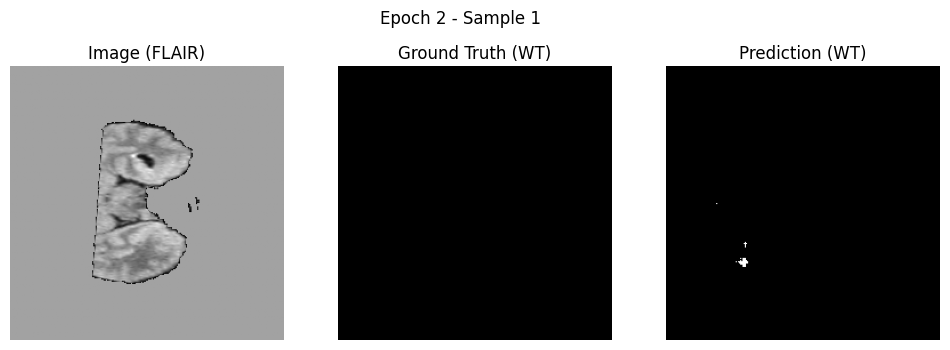

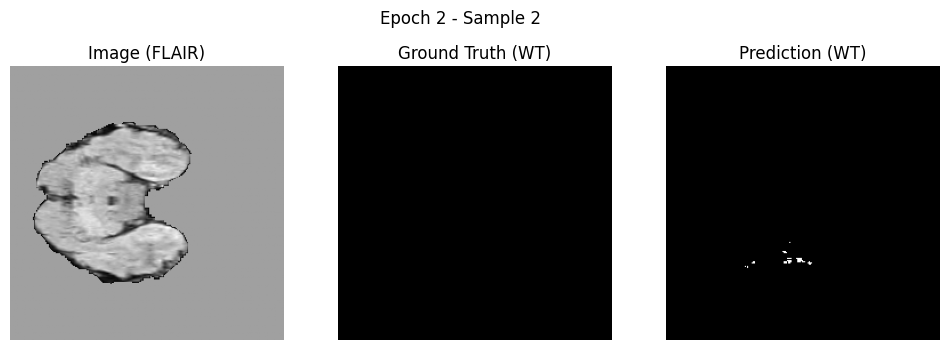

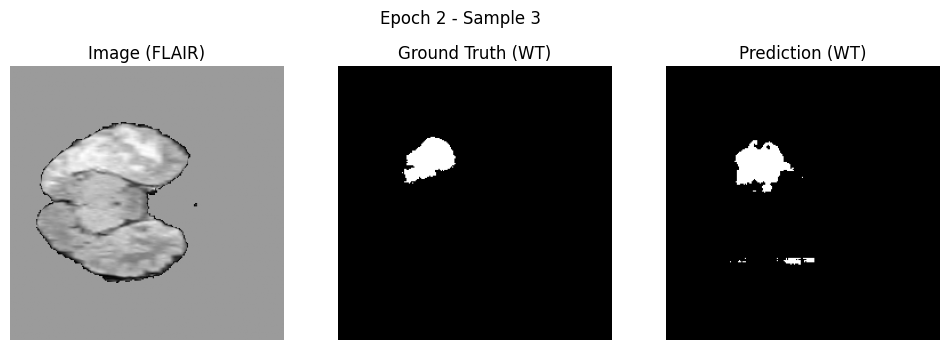

Current Mean Dice: 0.6396
Saved new best model refined.
----------
Refined Epoch 3/20
200/1000, train_loss: 0.8674
400/1000, train_loss: 0.0564
600/1000, train_loss: 0.9999
800/1000, train_loss: 0.1945
1000/1000, train_loss: 0.7608
Epoch 3 Avg Loss: 0.5101


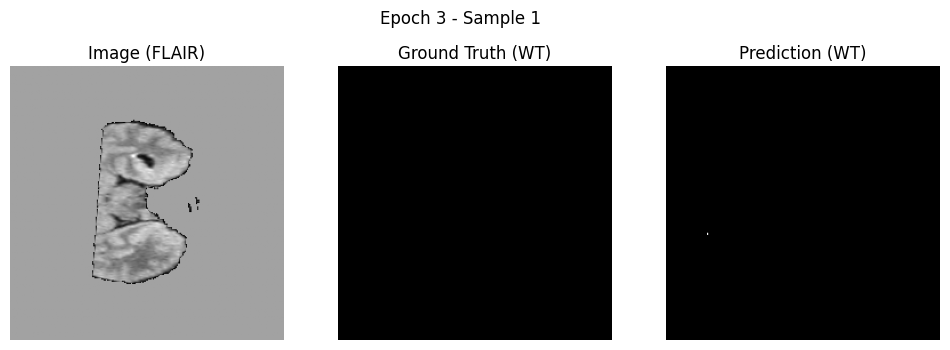

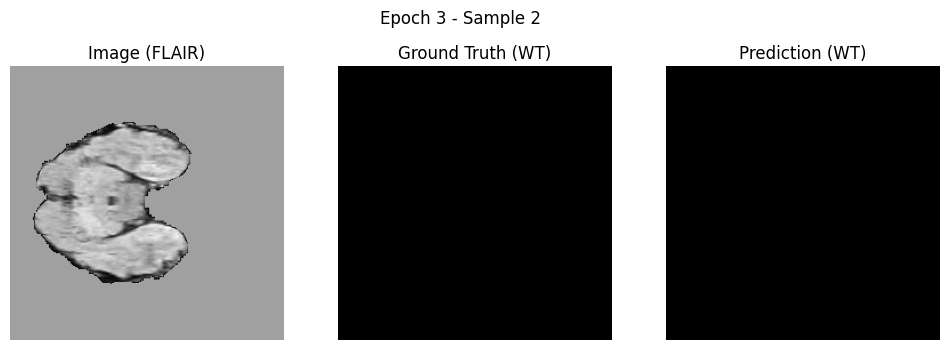

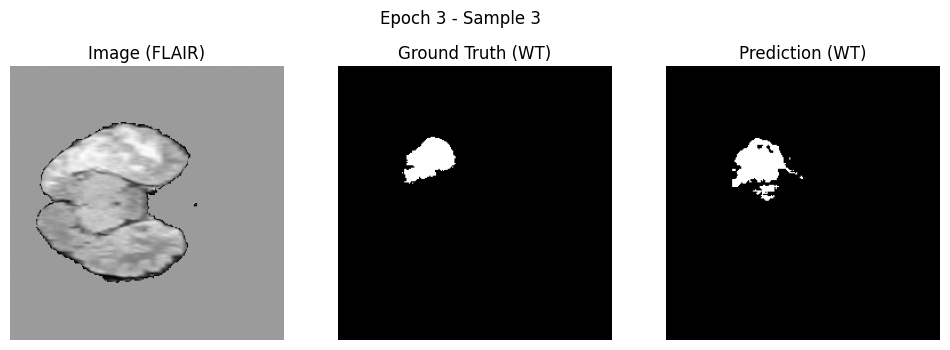

Current Mean Dice: 0.6735
Saved new best model refined.
----------
Refined Epoch 4/20
200/1000, train_loss: 0.0854
400/1000, train_loss: 1.0000
600/1000, train_loss: 0.5569
800/1000, train_loss: 0.7083
1000/1000, train_loss: 1.0000
Epoch 4 Avg Loss: 0.4919


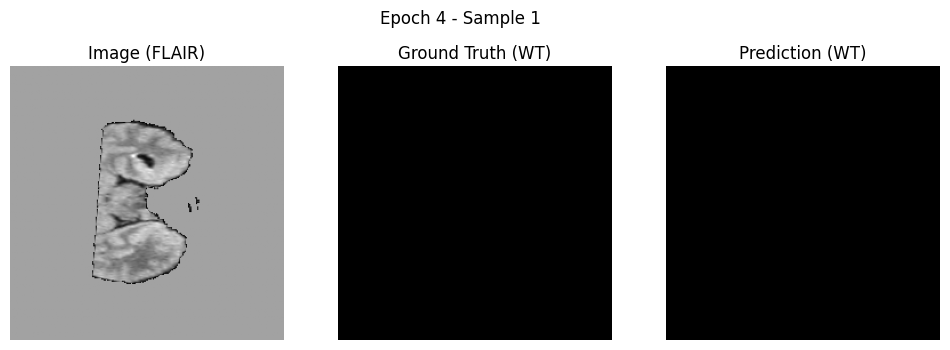

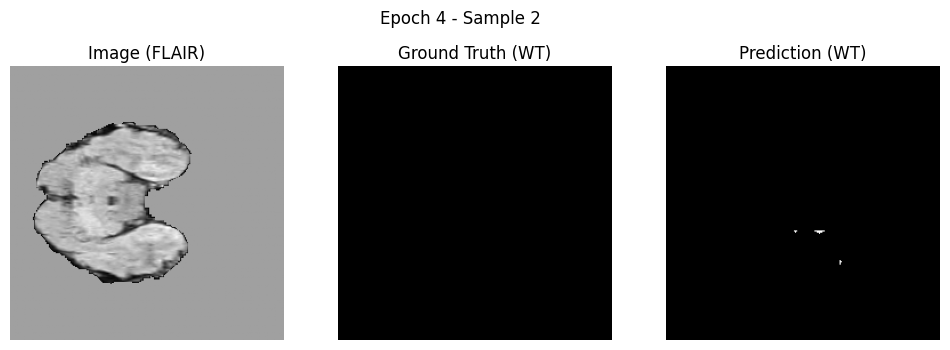

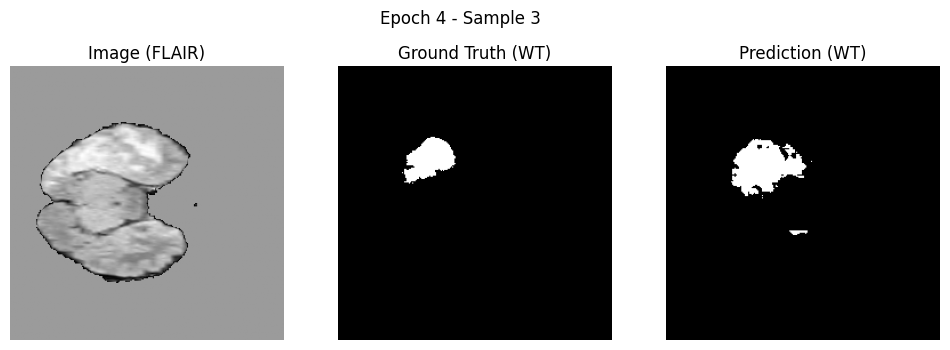

Current Mean Dice: 0.6611
----------
Refined Epoch 5/20
200/1000, train_loss: 0.3134
400/1000, train_loss: 0.7182
600/1000, train_loss: 0.1028
800/1000, train_loss: 1.0000
1000/1000, train_loss: 0.9866
Epoch 5 Avg Loss: 0.4836


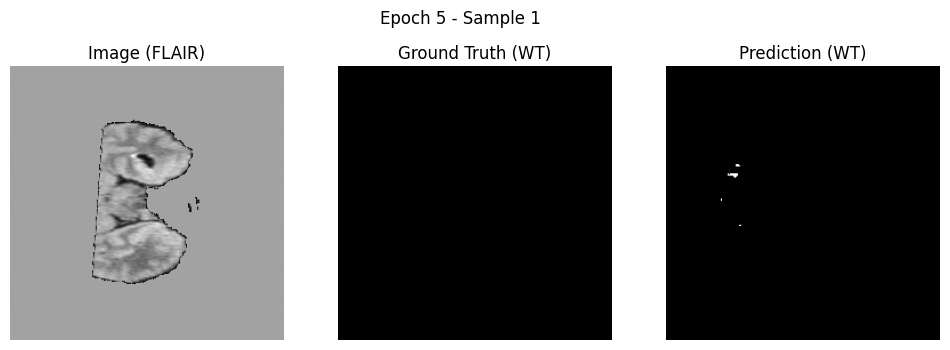

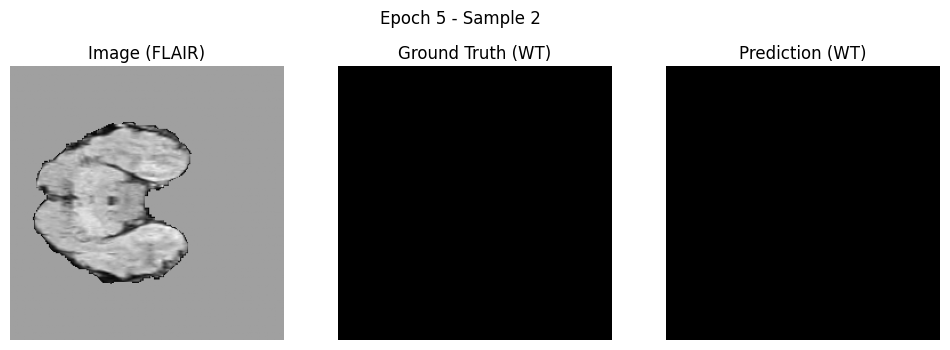

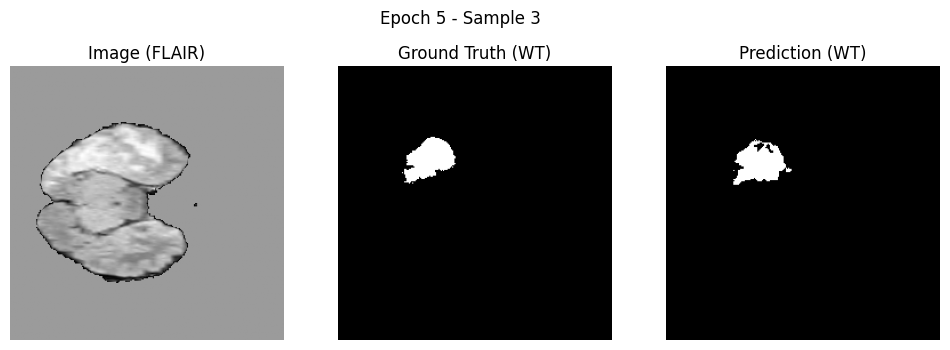

Current Mean Dice: 0.6735
Saved new best model refined.
----------
Refined Epoch 6/20
200/1000, train_loss: 0.0367
400/1000, train_loss: 0.0355
600/1000, train_loss: 0.1465
800/1000, train_loss: 1.0000
1000/1000, train_loss: 0.0358
Epoch 6 Avg Loss: 0.4688


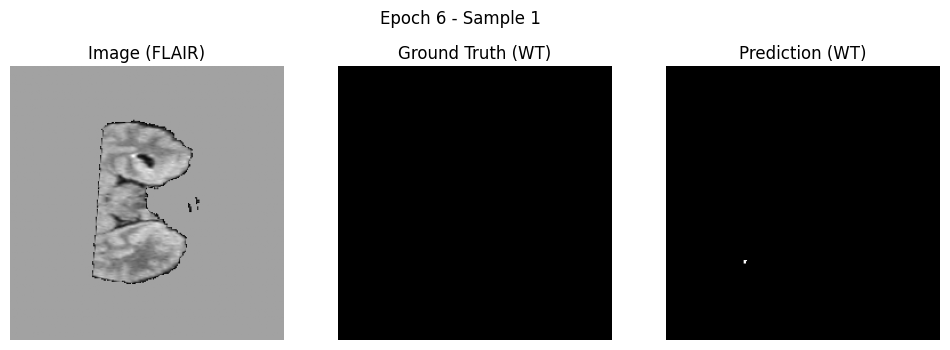

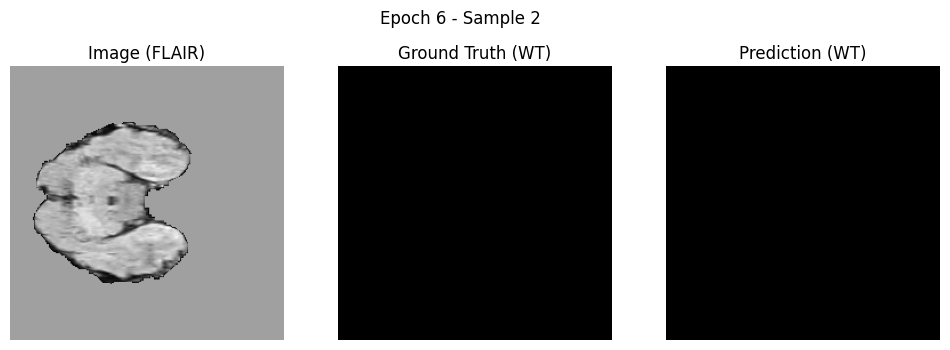

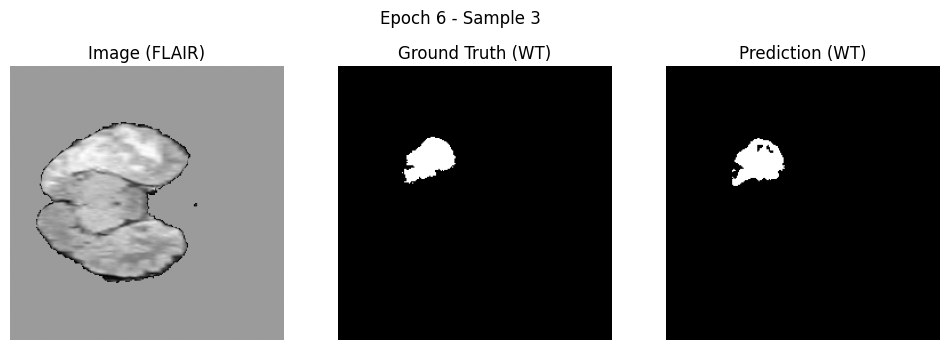

Current Mean Dice: 0.7299
Saved new best model refined.
----------
Refined Epoch 7/20
200/1000, train_loss: 0.0608
400/1000, train_loss: 0.2318
600/1000, train_loss: 0.0480
800/1000, train_loss: 0.1531
1000/1000, train_loss: 1.0000
Epoch 7 Avg Loss: 0.4733


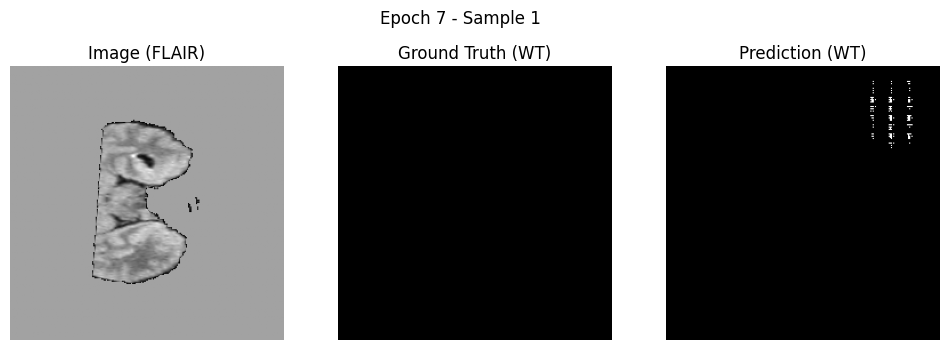

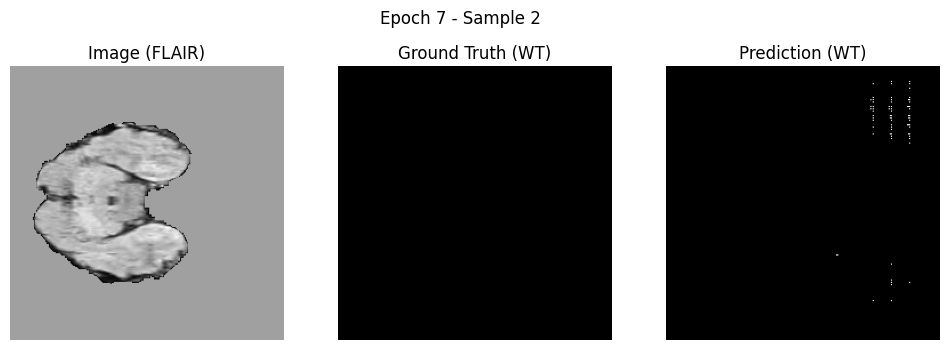

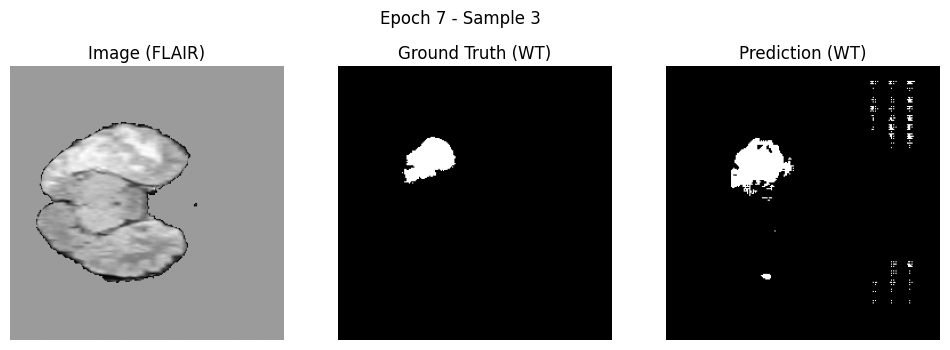

Current Mean Dice: 0.6328
----------
Refined Epoch 8/20
200/1000, train_loss: 1.0000
400/1000, train_loss: 1.0000
600/1000, train_loss: 0.1658
800/1000, train_loss: 1.0000
1000/1000, train_loss: 1.0000
Epoch 8 Avg Loss: 0.4485


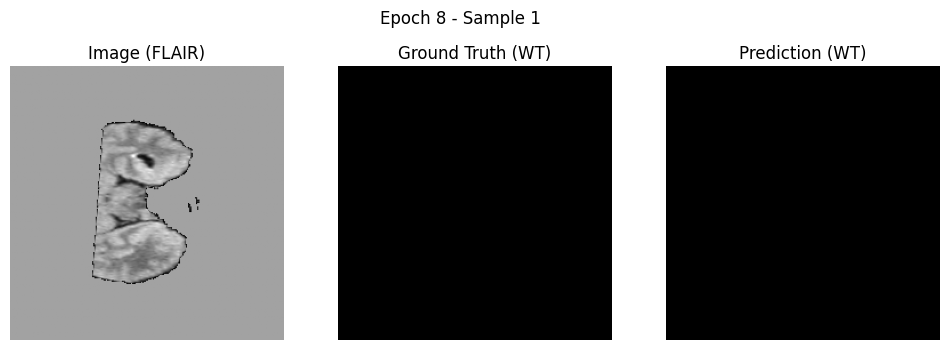

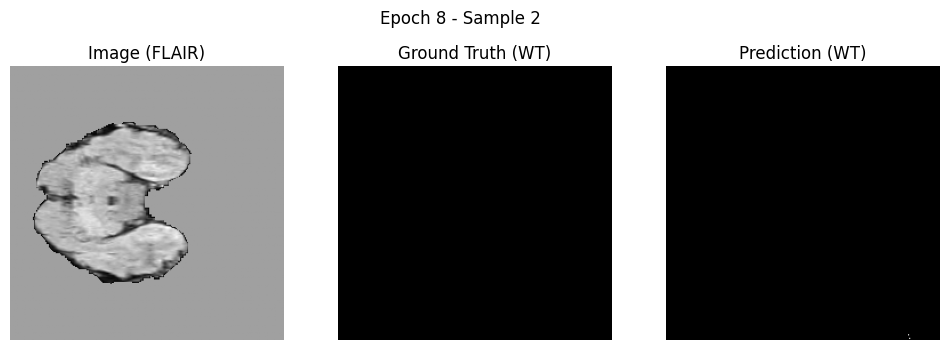

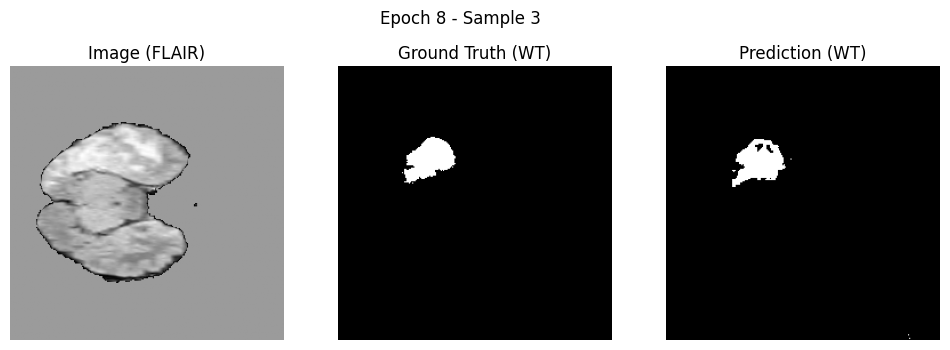

Current Mean Dice: 0.7031
----------
Refined Epoch 9/20
200/1000, train_loss: 0.0716
400/1000, train_loss: 0.1525
600/1000, train_loss: 0.0803
800/1000, train_loss: 0.7574
1000/1000, train_loss: 1.0000
Epoch 9 Avg Loss: 0.4537


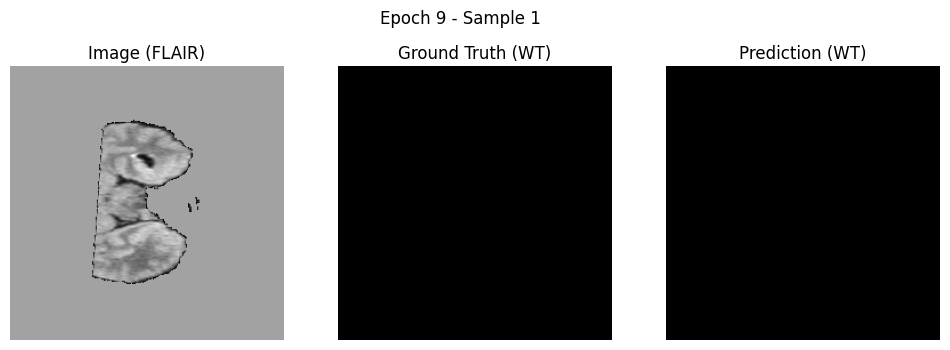

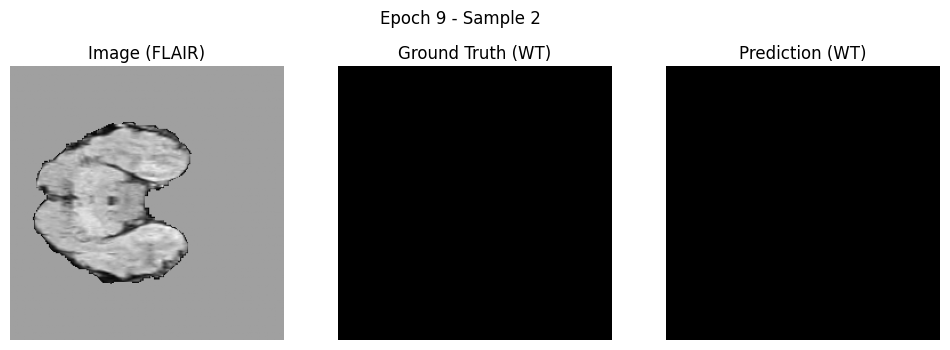

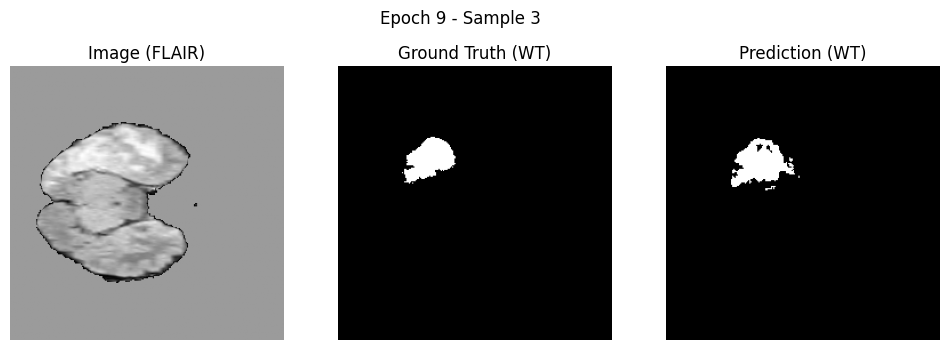

Current Mean Dice: 0.7007
----------
Refined Epoch 10/20
200/1000, train_loss: 0.5457
400/1000, train_loss: 0.0882
600/1000, train_loss: 1.0000
800/1000, train_loss: 0.0680
1000/1000, train_loss: 0.0465
Epoch 10 Avg Loss: 0.4736


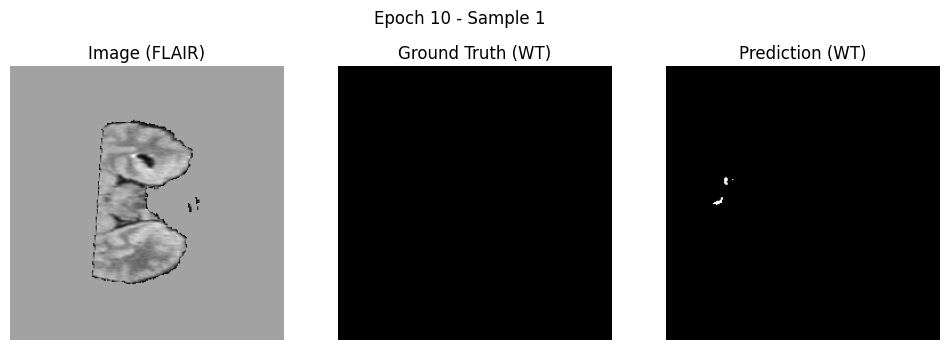

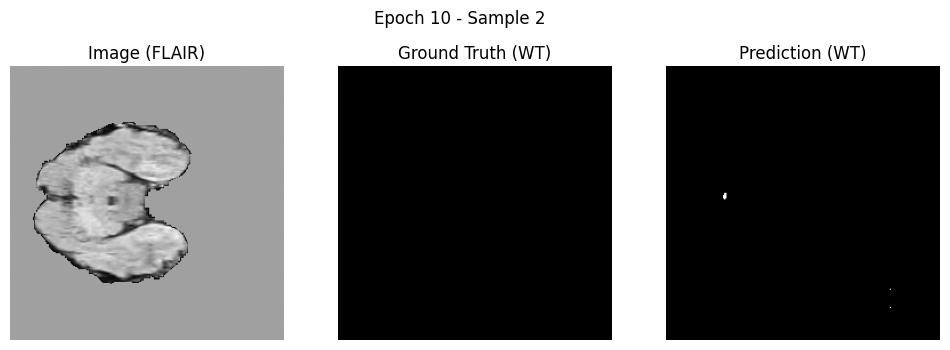

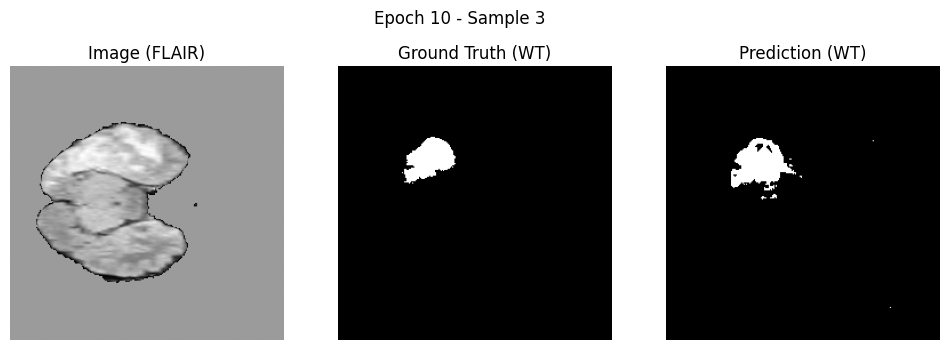

Current Mean Dice: 0.6935
----------
Refined Epoch 11/20
200/1000, train_loss: 1.0000
400/1000, train_loss: 0.0504
600/1000, train_loss: 0.0436
800/1000, train_loss: 0.0644
1000/1000, train_loss: 1.0000
Epoch 11 Avg Loss: 0.4461


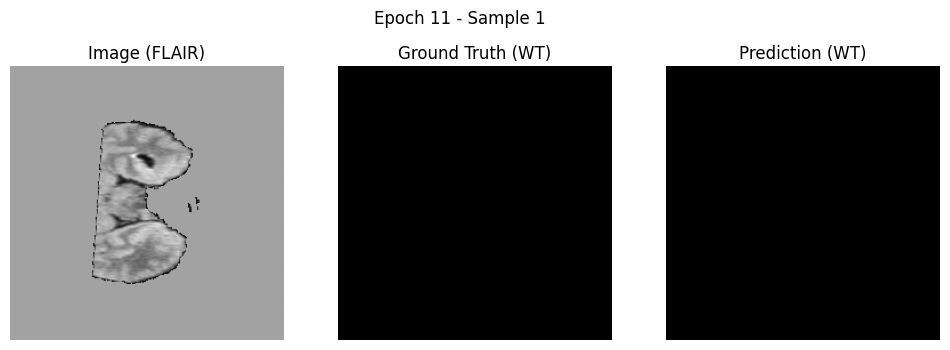

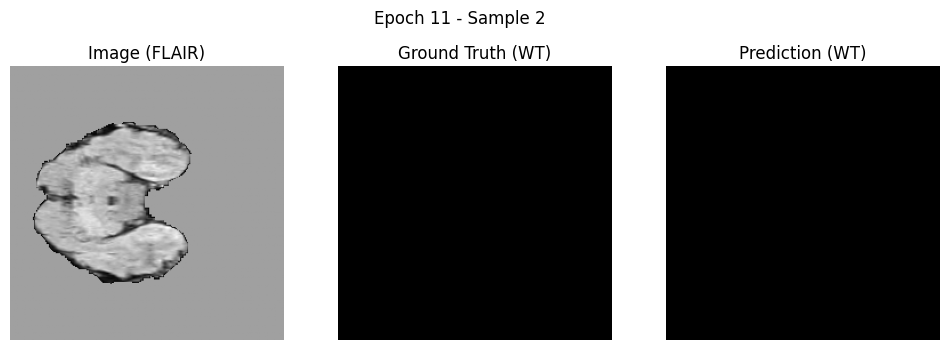

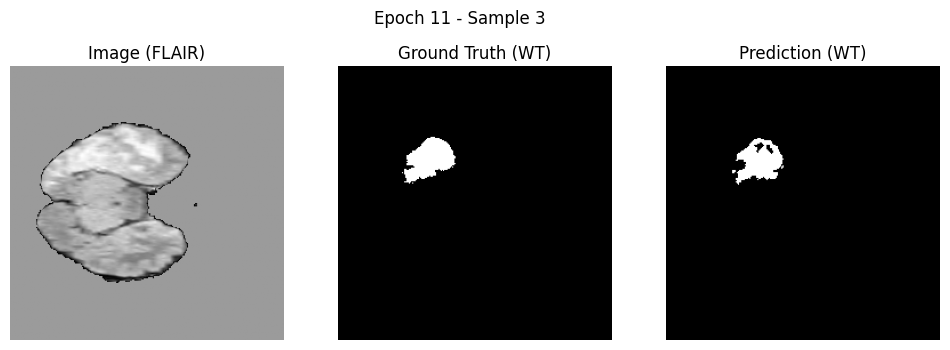

Current Mean Dice: 0.6798
----------
Refined Epoch 12/20
200/1000, train_loss: 1.0000
400/1000, train_loss: 0.0692
600/1000, train_loss: 0.0724
800/1000, train_loss: 0.7333
1000/1000, train_loss: 0.0482
Epoch 12 Avg Loss: 0.4640


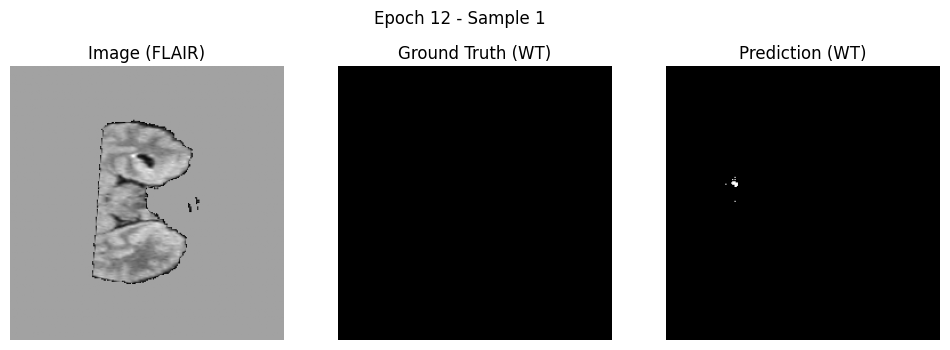

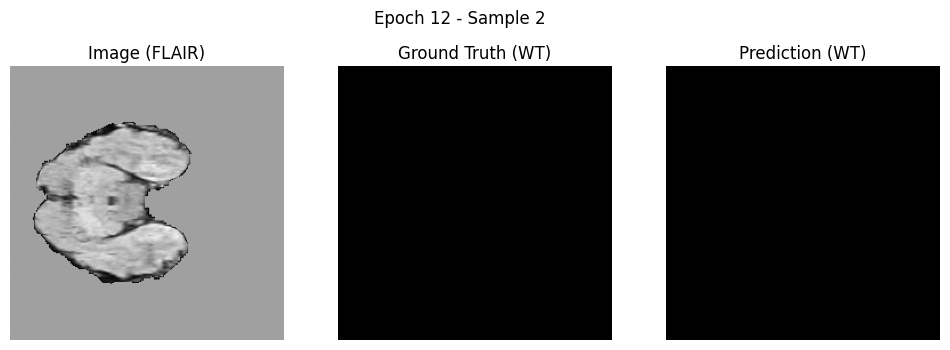

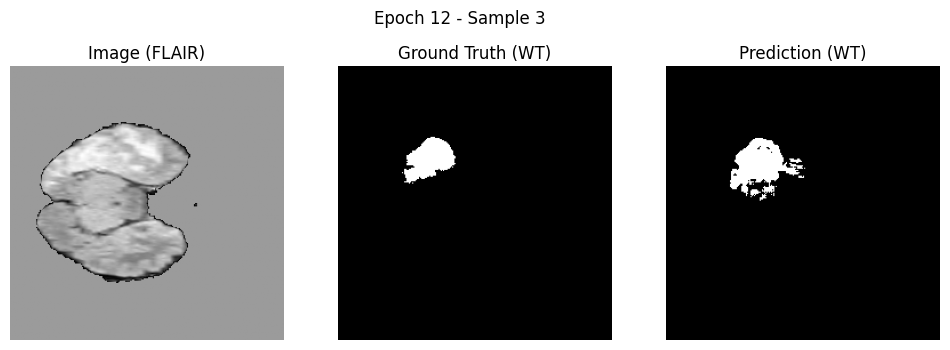

Current Mean Dice: 0.6982
----------
Refined Epoch 13/20
200/1000, train_loss: 0.1465
400/1000, train_loss: 1.0000
600/1000, train_loss: 1.0000
800/1000, train_loss: 0.8306
1000/1000, train_loss: 0.0285
Epoch 13 Avg Loss: 0.4826


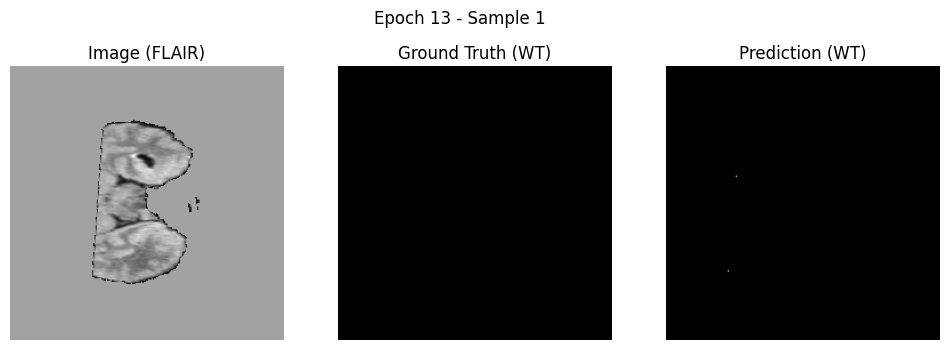

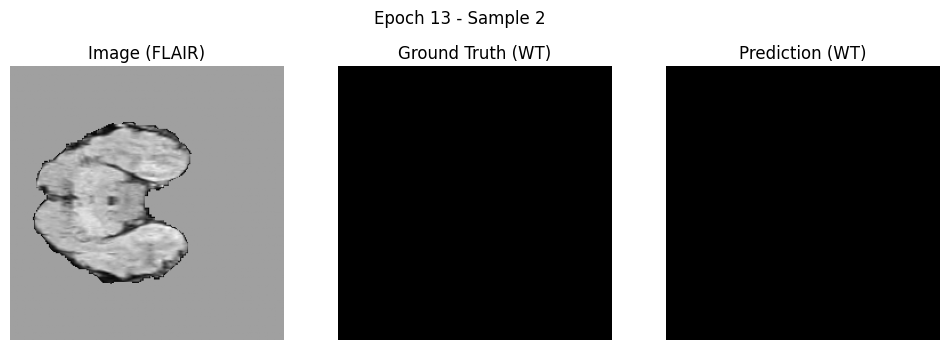

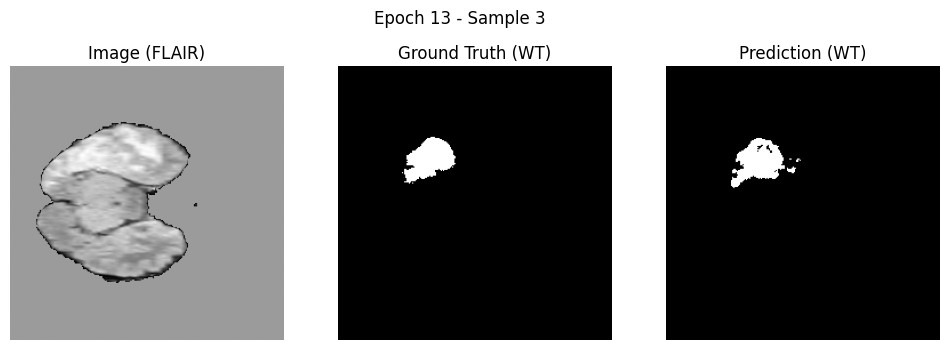

Current Mean Dice: 0.7273
----------
Refined Epoch 14/20
200/1000, train_loss: 1.0000
400/1000, train_loss: 0.0431
600/1000, train_loss: 1.0000
800/1000, train_loss: 0.0396
1000/1000, train_loss: 0.1907
Epoch 14 Avg Loss: 0.4706


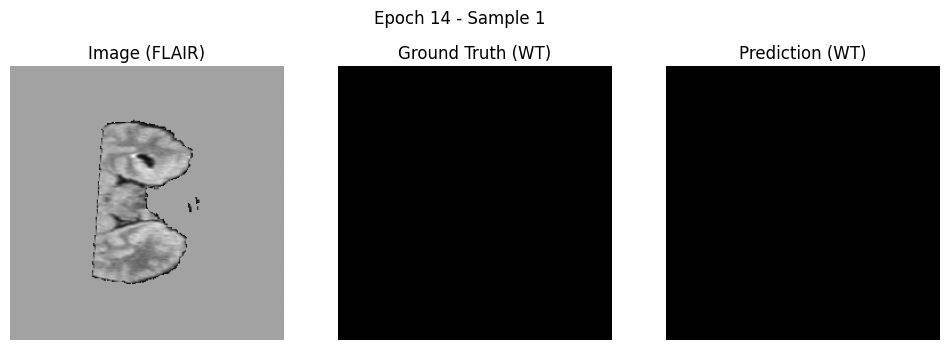

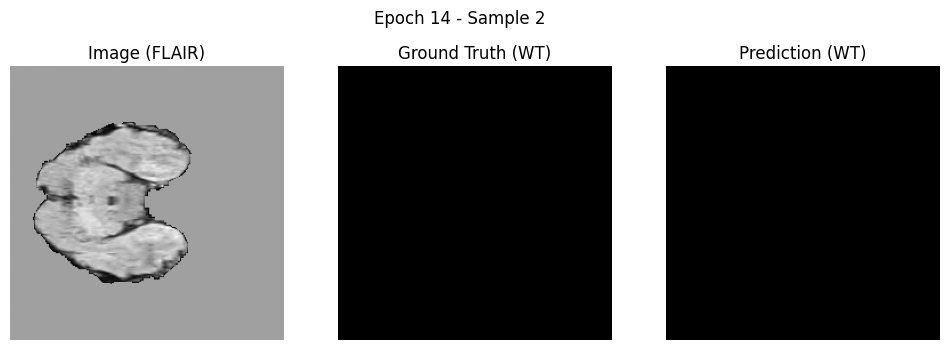

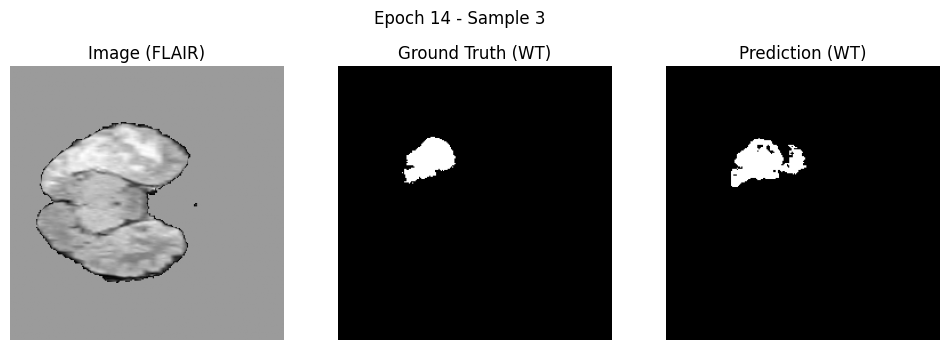

Current Mean Dice: 0.7321
Saved new best model refined.
----------
Refined Epoch 15/20
200/1000, train_loss: 0.0253
400/1000, train_loss: 0.1379
600/1000, train_loss: 0.7539
800/1000, train_loss: 0.0877
1000/1000, train_loss: 1.0000
Epoch 15 Avg Loss: 0.4621


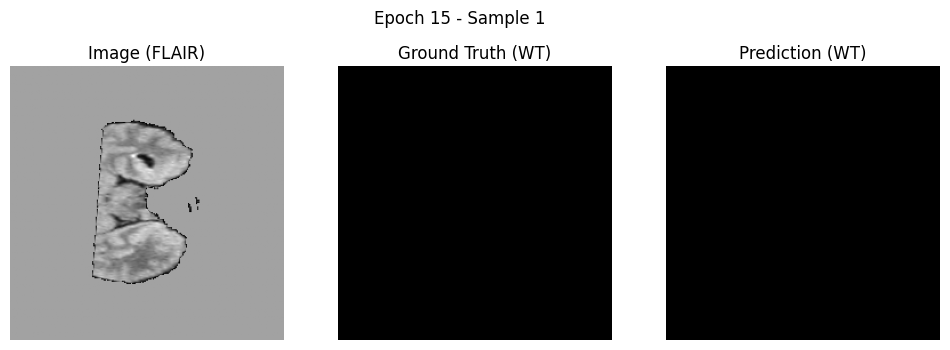

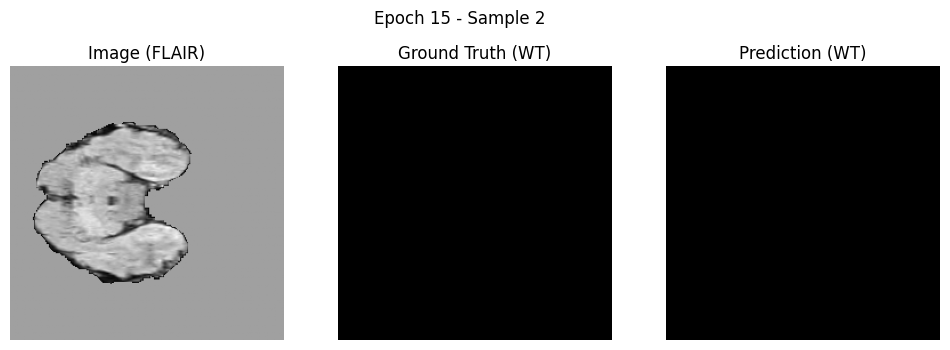

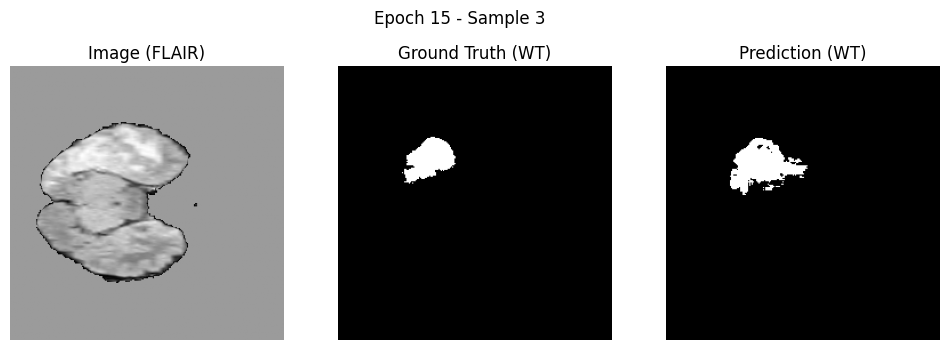

Current Mean Dice: 0.7466
Saved new best model refined.
----------
Refined Epoch 16/20
200/1000, train_loss: 0.0703
400/1000, train_loss: 1.0000
600/1000, train_loss: 0.2876
800/1000, train_loss: 0.2245
1000/1000, train_loss: 0.7866
Epoch 16 Avg Loss: 0.4625


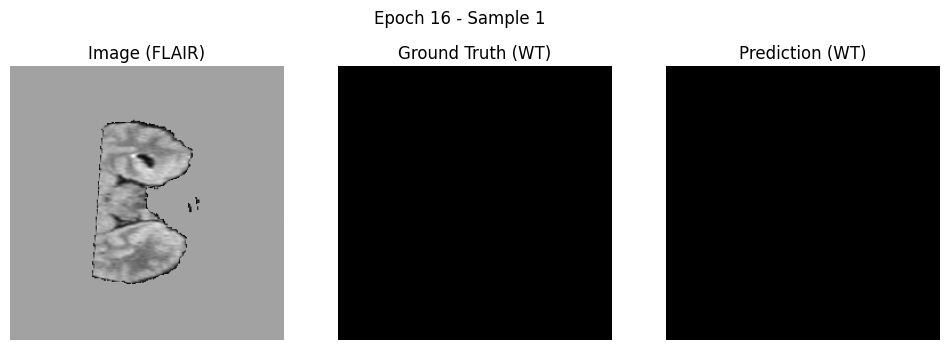

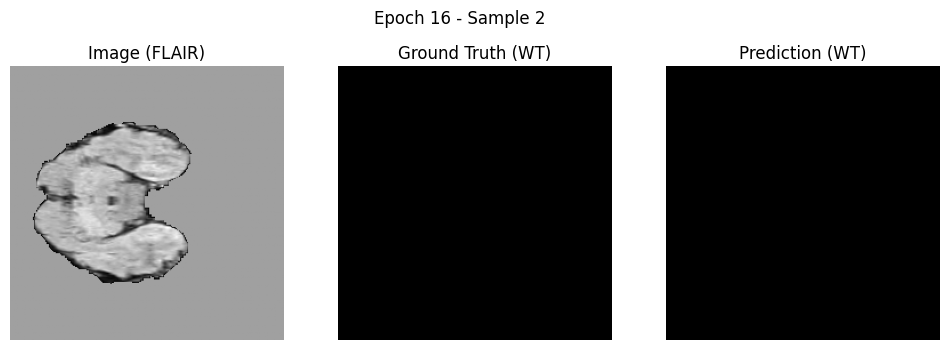

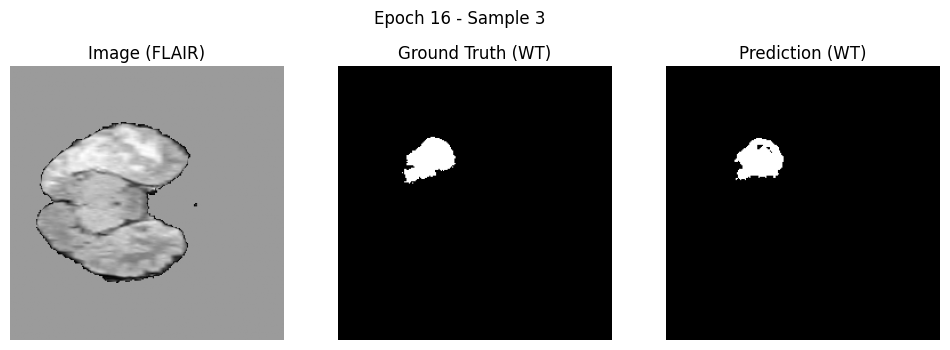

Current Mean Dice: 0.7045
----------
Refined Epoch 17/20
200/1000, train_loss: 0.0657
400/1000, train_loss: 0.6761
600/1000, train_loss: 1.0000
800/1000, train_loss: 0.6787
1000/1000, train_loss: 0.9995
Epoch 17 Avg Loss: 0.4580


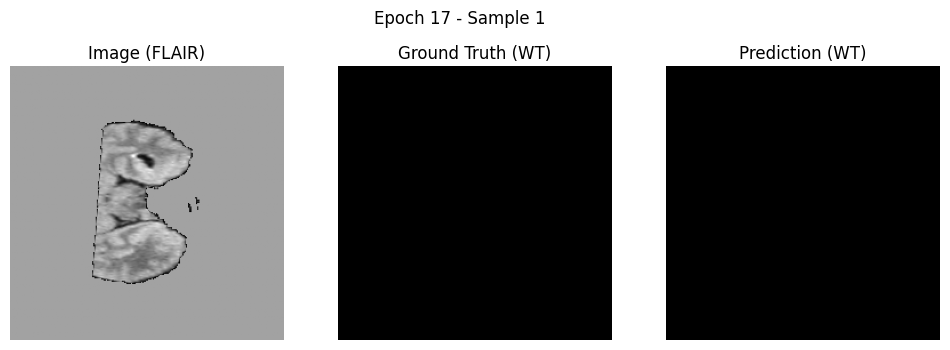

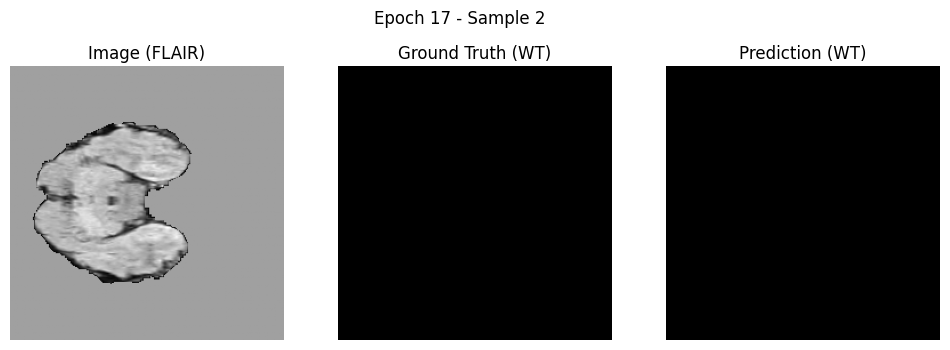

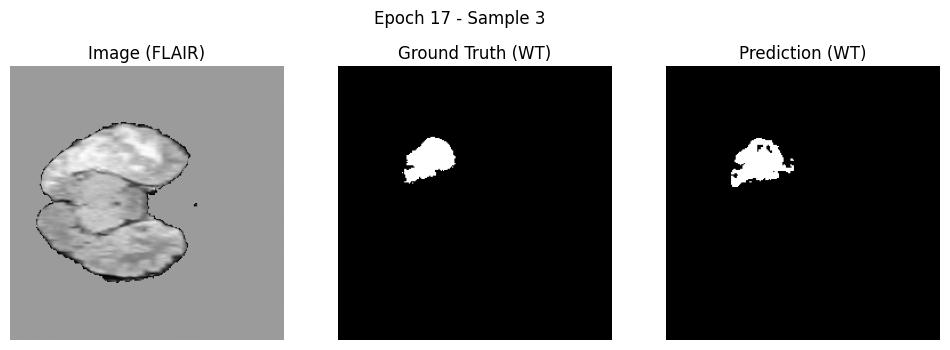

Current Mean Dice: 0.7428
----------
Refined Epoch 18/20
200/1000, train_loss: 1.0000
400/1000, train_loss: 0.0260
600/1000, train_loss: 0.0498
800/1000, train_loss: 0.0767
1000/1000, train_loss: 0.1247
Epoch 18 Avg Loss: 0.4618


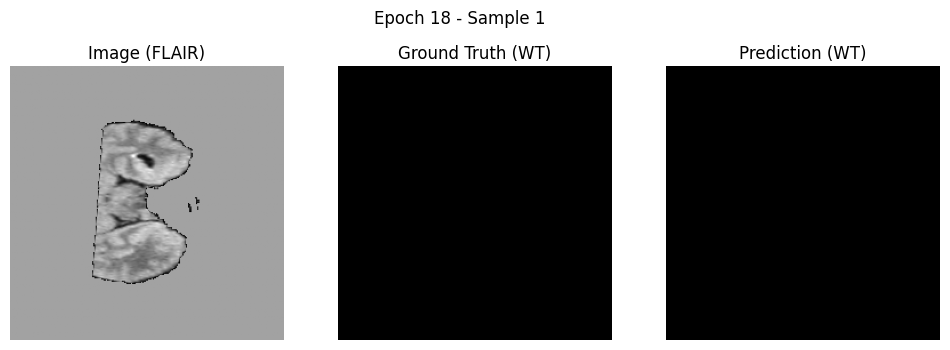

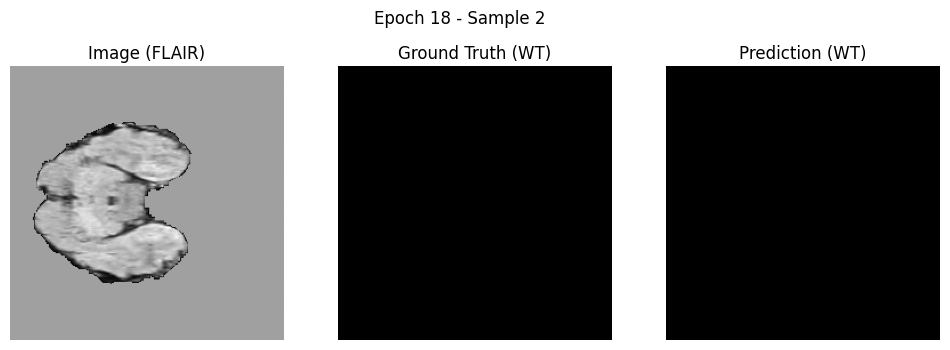

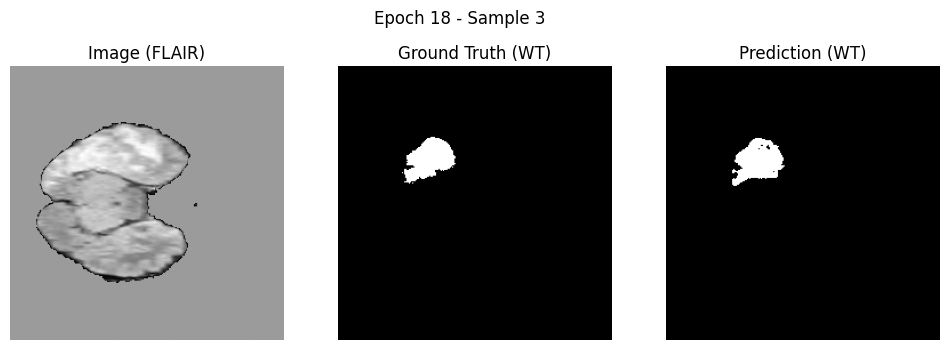

Current Mean Dice: 0.7446
----------
Refined Epoch 19/20
200/1000, train_loss: 1.0000
400/1000, train_loss: 1.0000
600/1000, train_loss: 0.1204
800/1000, train_loss: 0.1802
1000/1000, train_loss: 0.6744
Epoch 19 Avg Loss: 0.4674


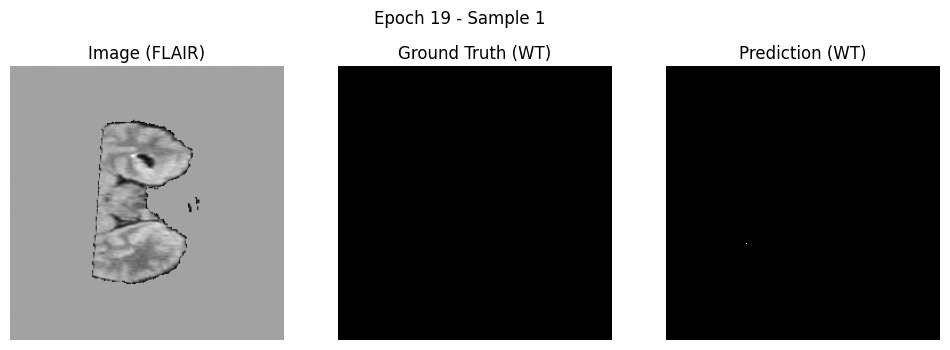

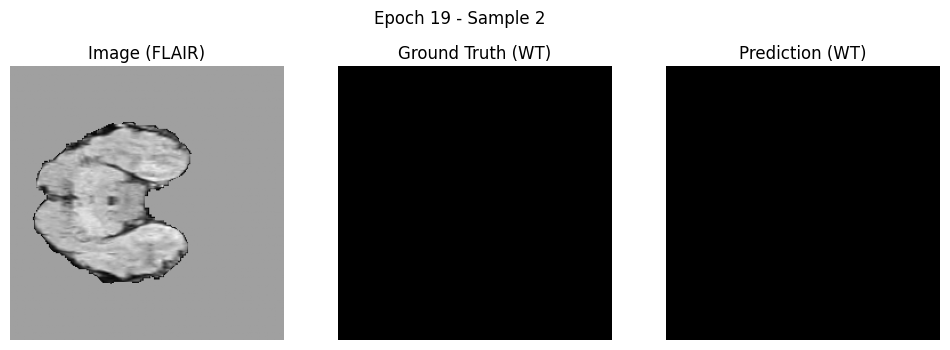

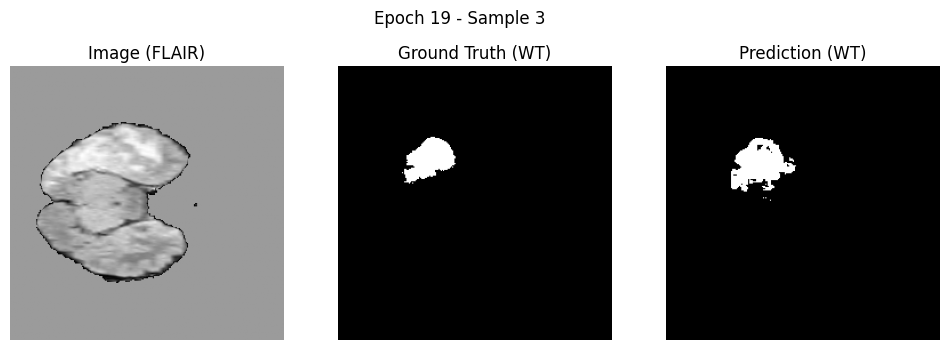

Current Mean Dice: 0.7181
----------
Refined Epoch 20/20
200/1000, train_loss: 0.7049
400/1000, train_loss: 0.0271
600/1000, train_loss: 1.0000
800/1000, train_loss: 1.0000
1000/1000, train_loss: 0.1259
Epoch 20 Avg Loss: 0.4755


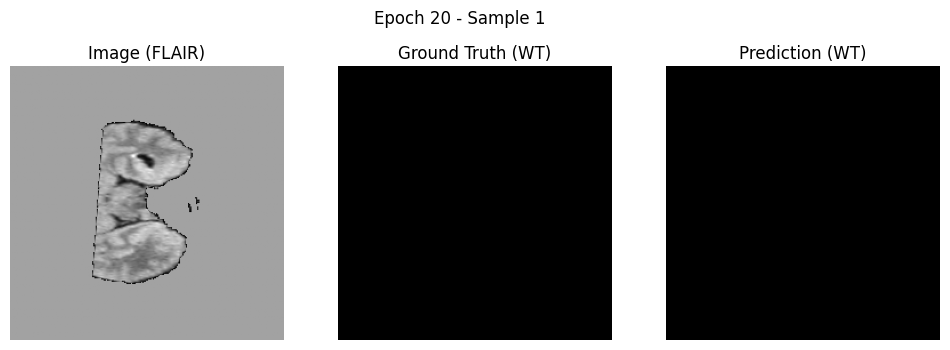

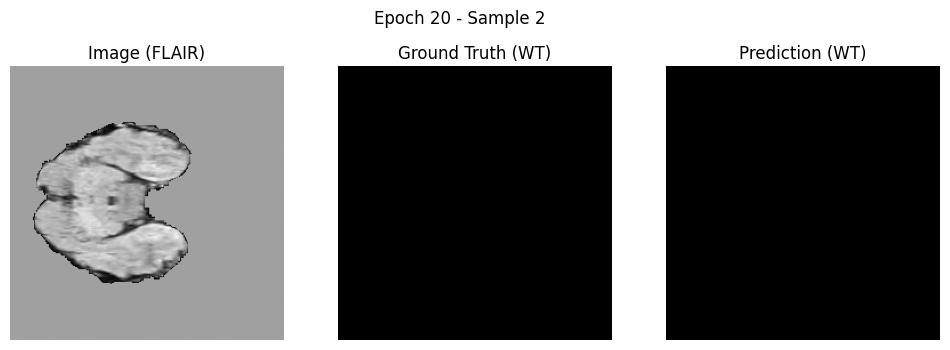

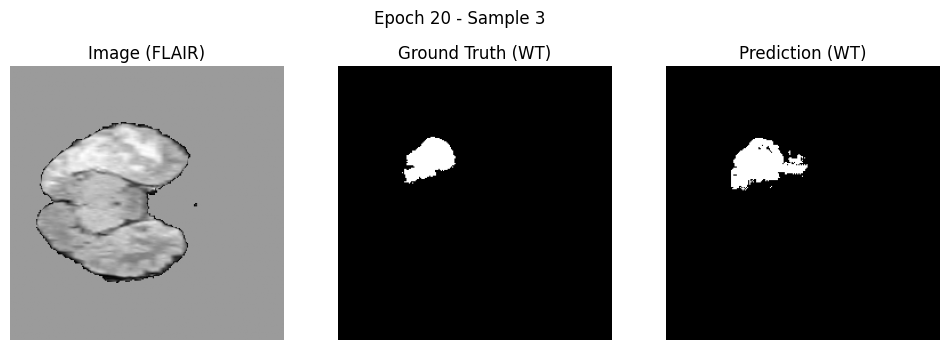

Current Mean Dice: 0.7625
Saved new best model refined.
Refined Training Complete!


In [6]:
# --- REFINED TRAINING LOOP ---
best_dice = -1 
print(f"Continuing training for {EXTRA_EPOCHS} epochs...")

for epoch in range(EXTRA_EPOCHS):
    print("-" * 10)
    print(f"Refined Epoch {epoch + 1}/{EXTRA_EPOCHS}")
    model.train()
    epoch_loss = 0
    step = 0
    
    for batch_data in train_loader:
        step += 1
        inputs, labels = batch_data["image"].to(device), batch_data["label"].to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        if step % 200 == 0:
             print(f"{step}/{len(train_ds)}, train_loss: {loss.item():.4f}")
    
    epoch_loss /= step
    print(f"Epoch {epoch + 1} Avg Loss: {epoch_loss:.4f}")
    
    # Validate
    model.eval()
    with torch.no_grad():
        visualize_results(model, val_loader, device, num_samples=3, epoch=epoch+1)
        
        for val_data in val_loader:
            val_inputs, val_labels = val_data["image"].to(device), val_data["label"].to(device)
            val_outputs = sliding_window_inference(val_inputs, (96, 96, 96), 4, model)
            val_outputs = [i > 0.5 for i in decollate_batch(val_outputs)]
            val_labels = decollate_batch(val_labels)
            dice_metric(y_pred=val_outputs, y=val_labels)
            
        current_dice = dice_metric.aggregate().item()
        dice_metric.reset()
        print(f"Current Mean Dice: {current_dice:.4f}")
        
        if current_dice > best_dice:
            best_dice = current_dice
            torch.save(model.state_dict(), "best_metric_model_refined.pth")
            print("Saved new best model refined.")
            
print("Refined Training Complete!")

In [7]:
# --- 8. FINAL EVALUATION & METRICS ---
from monai.metrics import HausdorffDistanceMetric

# Load Best Model
if os.path.exists("best_metric_model_refined.pth"):
    model.load_state_dict(torch.load("best_metric_model_refined.pth"))
    print("Loaded Refined Model.")
else:
    model.load_state_dict(torch.load("best_metric_model.pth"))
    print("Loaded Base Model.")

model.eval()

# Init Metrics
dice_metric_batch = DiceMetric(include_background=True, reduction="mean_batch", get_not_nans=False)
hausdorff_metric = HausdorffDistanceMetric(include_background=True, reduction="mean_batch", percentile=95)

print("Running Final Evaluation on Validation Set...")
with torch.no_grad():
    for val_data in val_loader:
        val_inputs, val_labels = val_data["image"].to(device), val_data["label"].to(device)
        val_outputs = sliding_window_inference(val_inputs, (96, 96, 96), 4, model)
        
        # Binarize
        val_outputs_bin = [i > 0.5 for i in decollate_batch(val_outputs)]
        val_labels_bin = decollate_batch(val_labels)
        
        # Compute Metrics
        dice_metric_batch(y_pred=val_outputs_bin, y=val_labels_bin)
        hausdorff_metric(y_pred=val_outputs_bin, y=val_labels_bin)

    # Aggregate
    mean_dice_per_class = dice_metric_batch.aggregate()
    mean_hd95_per_class = hausdorff_metric.aggregate()
    
    dice_metric_batch.reset()
    hausdorff_metric.reset()

    # Report (WT, TC, ET)
    class_names = ["Whole Tumor", "Tumor Core", "Enhancing Tumor"]
    print("\n--- Performance Report ---")
    for i, name in enumerate(class_names):
        dice_score = mean_dice_per_class[i].item()
        hd95_score = mean_hd95_per_class[i].item()
        print(f"{name}: Dice={dice_score:.4f}, HD95={hd95_score:.4f}")
        
    print(f"\nMean Dice: {torch.mean(mean_dice_per_class).item():.4f}")
    print(f"Mean HD95: {torch.mean(mean_hd95_per_class).item():.4f}")

Loaded Refined Model.
Running Final Evaluation on Validation Set...


monai.metrics.utils get_mask_edges:always_return_as_numpy: Argument `always_return_as_numpy` has been deprecated since version 1.5.0. It will be removed in version 1.7.0. The option is removed and the return type will always be equal to the input type.
the ground truth of class 2 is all 0, this may result in nan/inf distance.
the ground truth of class 0 is all 0, this may result in nan/inf distance.
the prediction of class 2 is all 0, this may result in nan/inf distance.



--- Performance Report ---
Whole Tumor: Dice=0.7258, HD95=24.5890
Tumor Core: Dice=0.8525, HD95=23.9082
Enhancing Tumor: Dice=0.7194, HD95=24.3269

Mean Dice: 0.7659
Mean HD95: 24.2747
